In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns

In [2]:
stock_market = pd.read_csv("/content/stockpricepredictiondata.csv")
stock_market.head()

,Company,Date,Close/Last,Volume,Open,High,Low
0,AAPL,07/17/2023,$193.99,50520160,$191.90,$194.32,$191.81
1,AAPL,07/14/2023,$190.69,41616240,$190.23,$191.1799,$189.63
2,AAPL,07/13/2023,$190.54,41342340,$190.50,$191.19,$189.78
3,AAPL,07-12-2023,$189.77,60750250,$189.68,$191.70,$188.47
4,AAPL,07-11-2023,$188.08,46638120,$189.16,$189.30,$186.60


In [3]:
stock_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25160 entries, 0 to 25159
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Company     25160 non-null  object
 1   Date        25160 non-null  object
 2   Close/Last  25160 non-null  object
 3   Volume      25160 non-null  int64 
 4   Open        25160 non-null  object
 5   High        25160 non-null  object
 6   Low         25160 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


In [4]:
stock_market.describe()

,Volume
count,2.516000e+04
mean,5.131764e+07
std,6.399143e+07
min,1.143952e+06
25%,1.200394e+07
50%,2.672083e+07
75%,6.857269e+07
max,1.065209e+09


In [5]:
stock_market.sample(10)

,Company,Date,Close/Last,Volume,Open,High,Low
24569,NFLX,11/18/2015,$120.63,23315480,$117.94,$121.00,$116.10
7832,CSCO,05/26/2022,$44.99,28294660,$44.05,$45.5256,$44.05
2636,SBUX,01/23/2023,$106.21,6320513,$105.04,$106.89,$104.40
10709,QCOM,12/18/2020,$147.42,13288320,$150.7947,$150.7947,$146.1238
5549,MSFT,06/24/2021,$266.69,21446870,$266.16,$267.85,$265.47
5509,MSFT,08/20/2021,$304.36,40817650,$299.72,$305.84,$298.06
12164,QCOM,03-12-2015,$69.37,16003460,$70.00,$70.55,$69.20
9882,CSCO,04-07-2014,$22.85,55211040,$22.60,$23.07,$22.50
16064,AMZN,09-10-2019,$91.0275,52277580,$91.1375,$91.2905,$90.2668
5221,MSFT,10-12-2022,$225.75,21903940,$225.40,$227.86,$223.96


In [6]:
stock_market.isnull().sum()

Company       0
Date          0
Close/Last    0
Volume        0
Open          0
High          0
Low           0
dtype: int64

In [7]:
stock_market['Company'].unique()


array(['AAPL', 'SBUX', 'MSFT', 'CSCO', 'QCOM', 'META', 'AMZN', 'TSLA',
       'AMD', 'NFLX'], dtype=object)

In [8]:
stock_market.dtypes

Company       object
Date          object
Close/Last    object
Volume         int64
Open          object
High          object
Low           object
dtype: object

In [47]:
stocks_dataframe = pd.DataFrame(stock_market)
stocks_dataframe['Date'] = pd.to_datetime(stock_market['Date'], format='%m-%d-%Y', errors='coerce')
stocks_dataframe['Date'].fillna(pd.to_datetime(stock_market['Date'], format='%m/%d/%Y', errors='coerce'), inplace=True)
date_time_interval = stocks_dataframe['Date'].dt.normalize()

In [48]:
date_time_interval

0       2023-07-17
1       2023-07-14
2       2023-07-13
3       2023-07-12
4       2023-07-11
           ...    
25155   2013-07-24
25156   2013-07-23
25157   2013-07-22
25158   2013-07-19
25159   2013-07-18
Name: Date, Length: 25160, dtype: datetime64[ns]

In [11]:
stock_market.Date = date_time_interval

In [12]:
stock_market.dtypes

Company               object
Date          datetime64[ns]
Close/Last            object
Volume                 int64
Open                  object
High                  object
Low                   object
dtype: object

In [13]:
stock_market['Close/Last'] = stock_market['Close/Last'].map(lambda x: float(x.replace('$', '')))
stock_market['Open'] = stock_market['Open'].map(lambda x: float(x.replace('$', '')))
stock_market['High'] = stock_market['High'].map(lambda x: float(x.replace('$', '')))
stock_market['Low'] = stock_market['Low'].map(lambda x: float(x.replace('$', '')))




In [14]:
stock_market.dtypes

Company               object
Date          datetime64[ns]
Close/Last           float64
Volume                 int64
Open                 float64
High                 float64
Low                  float64
dtype: object

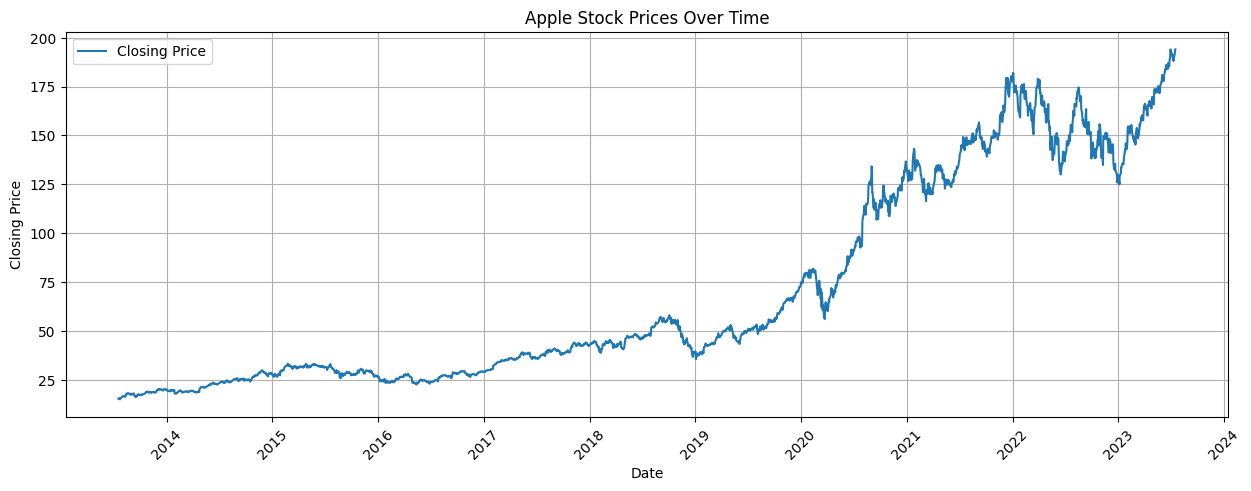

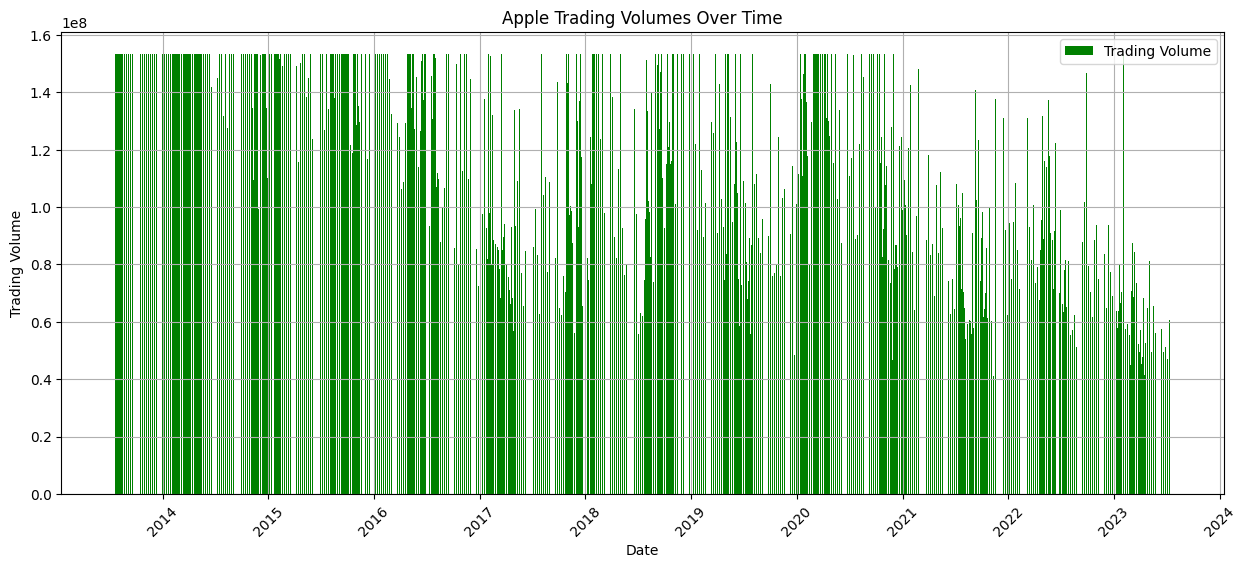

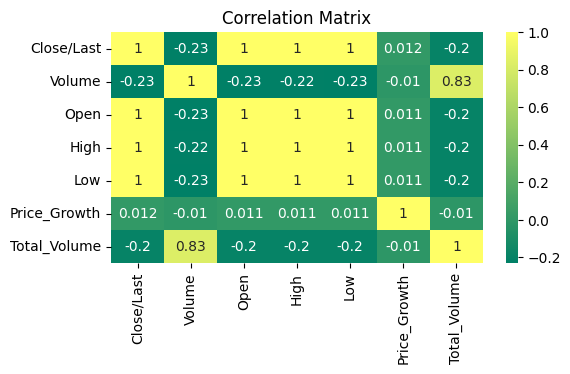

In [49]:
apple_data = stock_market[stock_market['Company'] == 'AAPL']

plt.figure(figsize=(15, 5))
plt.plot(apple_data['Date'], apple_data['Close/Last'], label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Apple Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(apple_data['Date'], apple_data['Volume'], label='Trading Volume', color='green')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Apple Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='summer')
plt.title('Correlation Matrix')
plt.show()

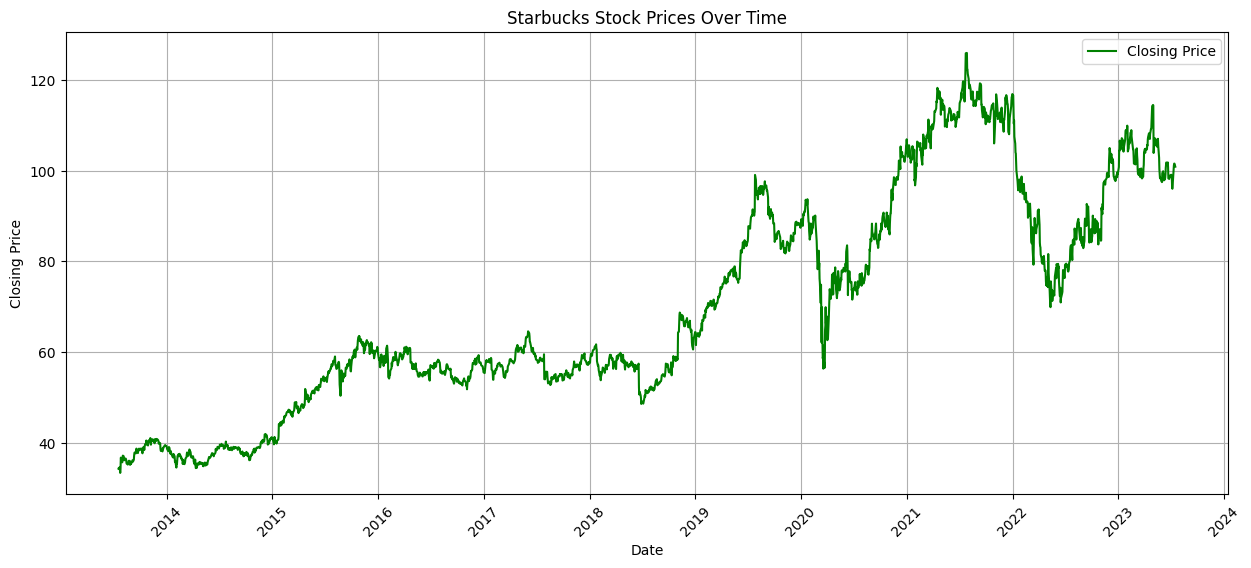

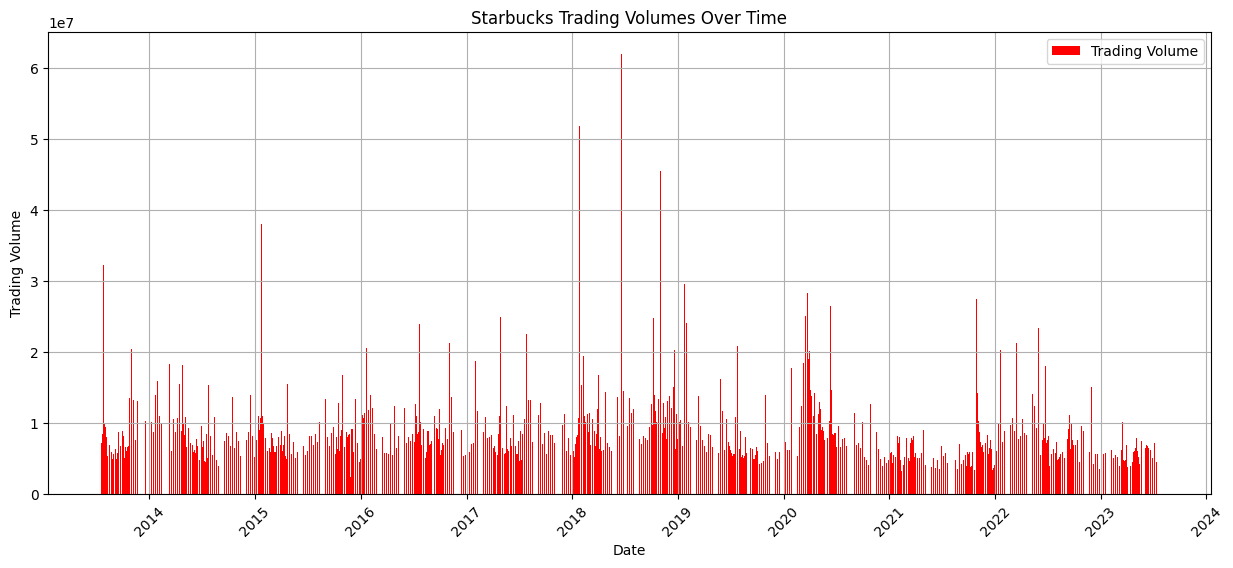

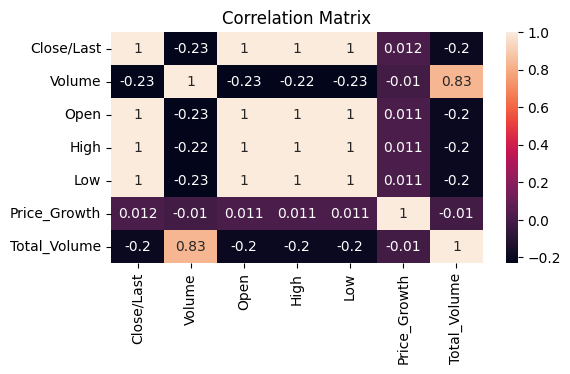

In [50]:
starbucks_data = stock_market[stock_market['Company'] == 'SBUX']

plt.figure(figsize=(15, 6))
plt.plot(starbucks_data['Date'], starbucks_data['Close/Last'], color='green',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Starbucks Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(starbucks_data['Date'], starbucks_data['Volume'], label='Trading Volume', color='red')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Starbucks Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

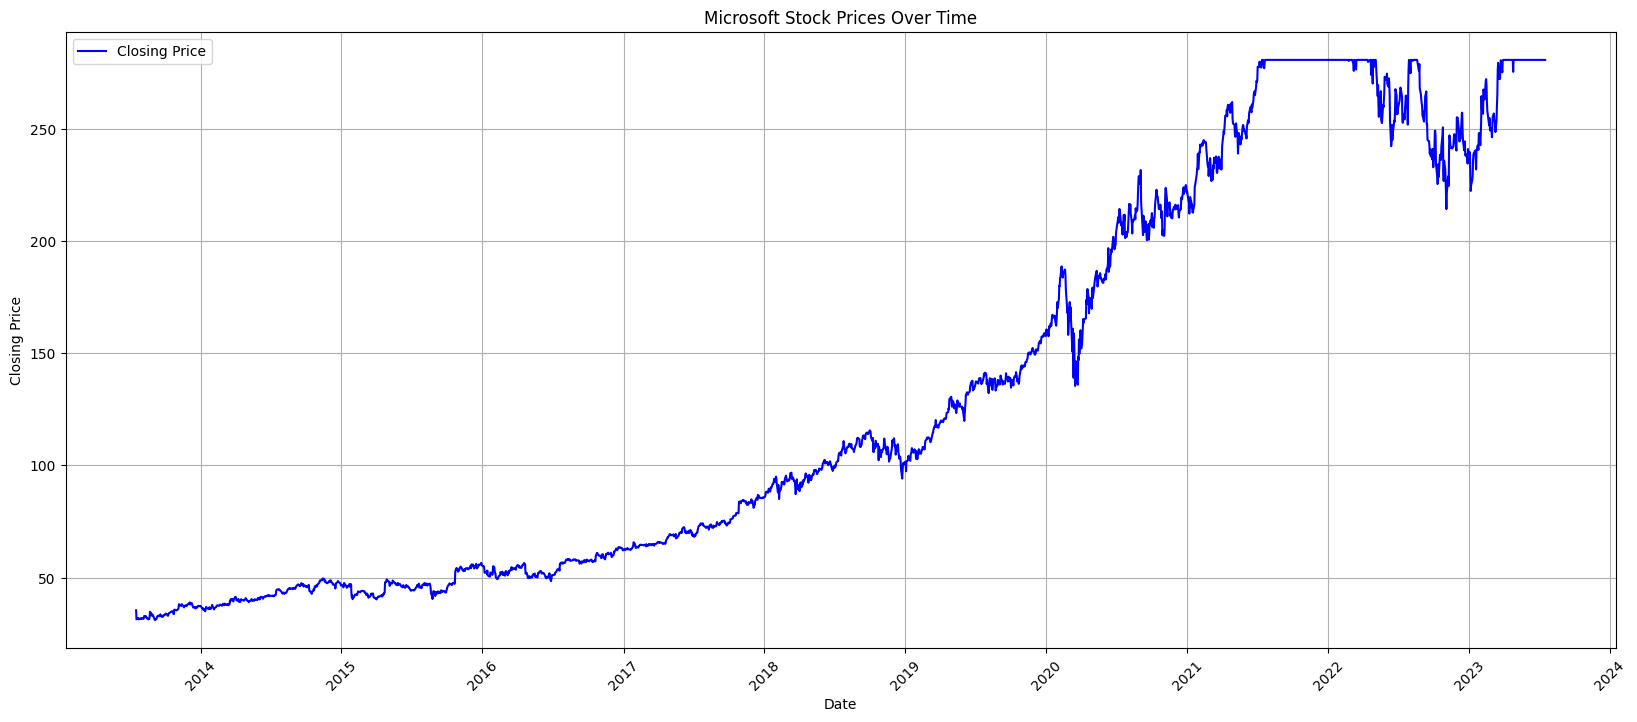

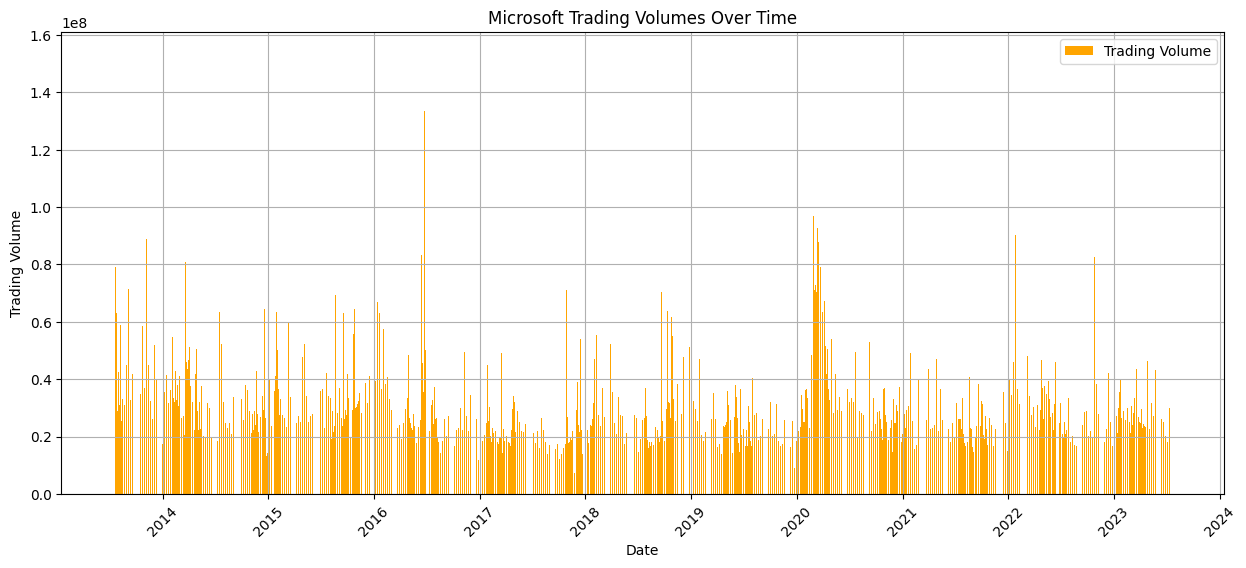

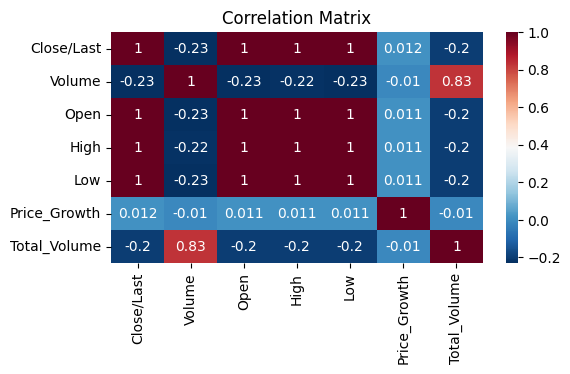

In [51]:
microsoft_data = stock_market[stock_market['Company'] == 'MSFT']

plt.figure(figsize=(20, 8))
plt.plot(microsoft_data['Date'],microsoft_data['Close/Last'], color='blue',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Microsoft Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(microsoft_data['Date'], microsoft_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Microsoft Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="RdBu_r")
plt.title('Correlation Matrix')
plt.show()

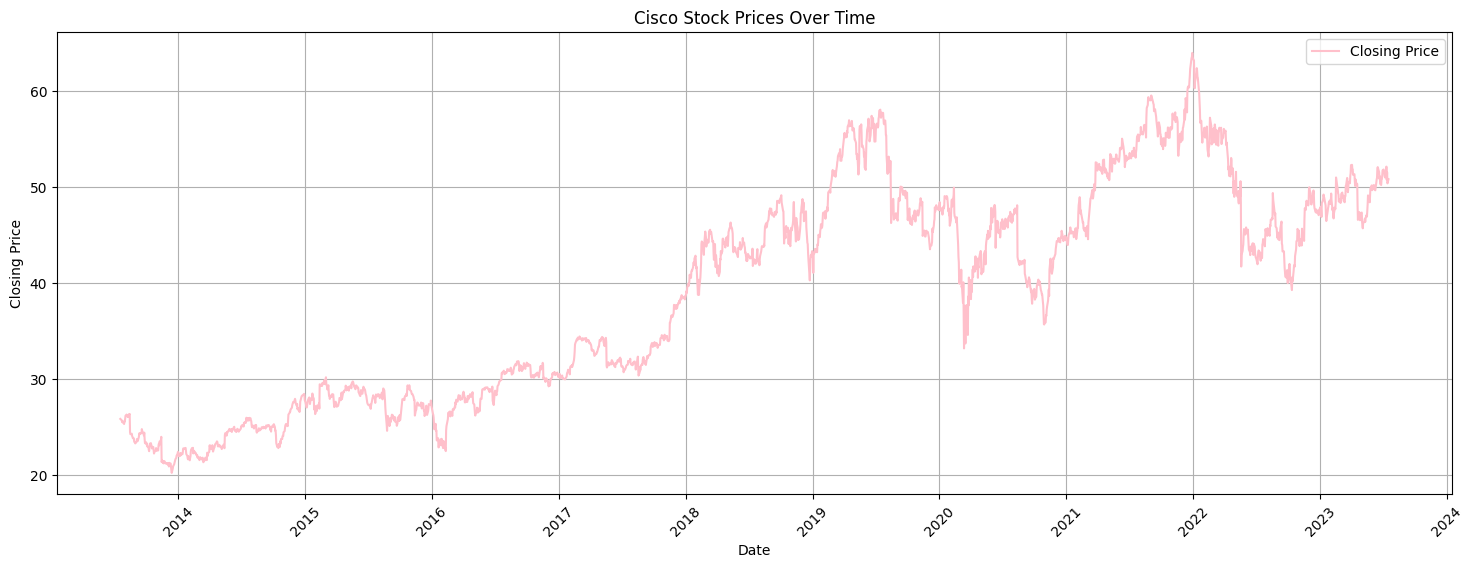

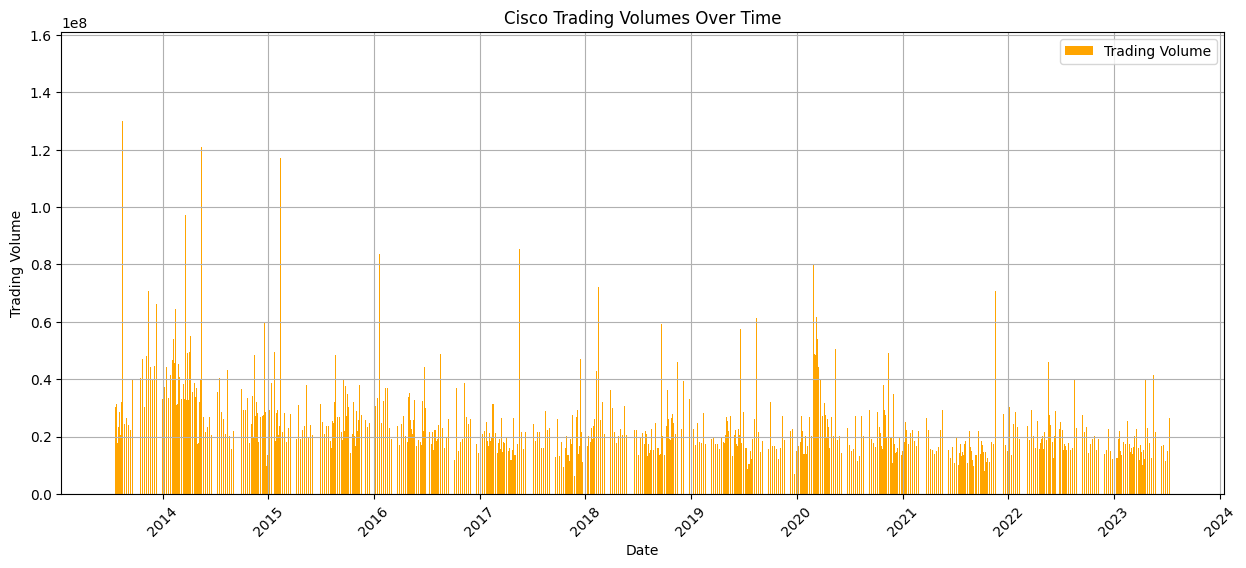

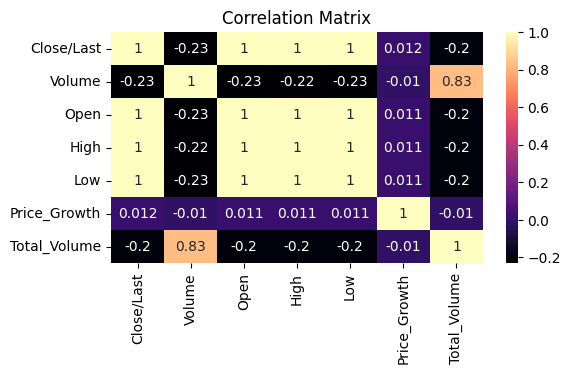

In [52]:
cisco_data = stock_market[stock_market['Company'] == 'CSCO']

plt.figure(figsize=(18, 6))
plt.plot(cisco_data['Date'], cisco_data['Close/Last'], color='pink',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Cisco Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(cisco_data['Date'], cisco_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Cisco Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="magma")
plt.title('Correlation Matrix')
plt.show()

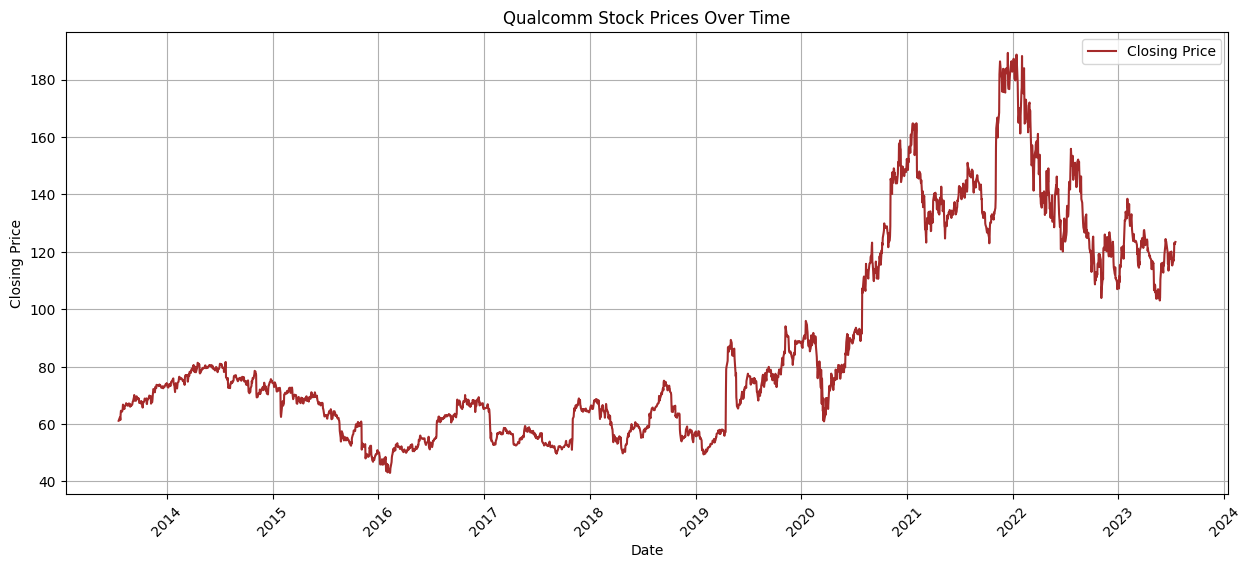

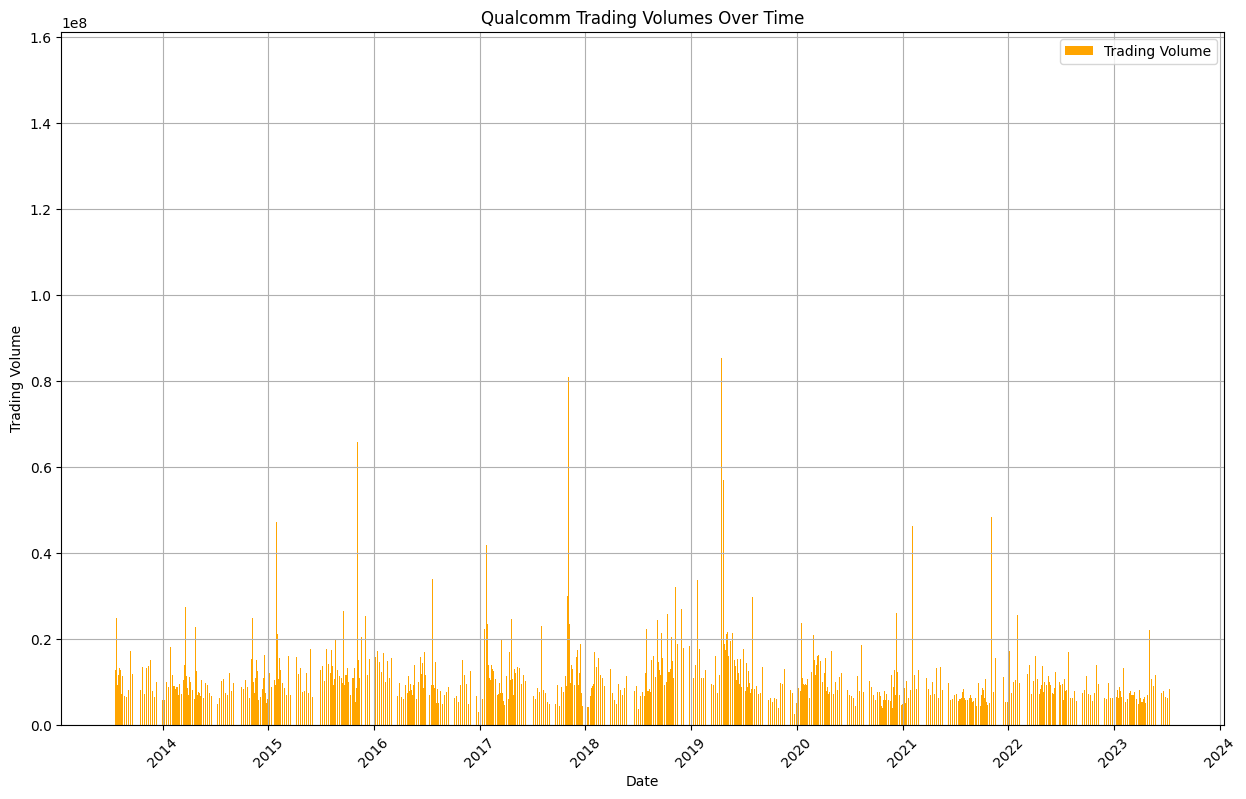

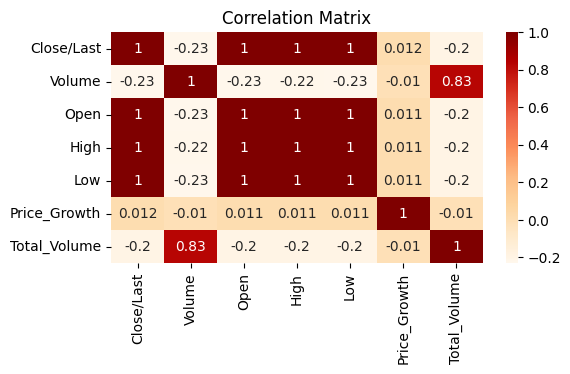

In [53]:
qualcomm_data = stock_market[stock_market['Company'] == 'QCOM']

plt.figure(figsize=(15, 6))
plt.plot(qualcomm_data['Date'], qualcomm_data['Close/Last'], color='brown',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Qualcomm Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 9))
plt.bar(qualcomm_data['Date'], qualcomm_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Qualcomm Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="OrRd")
plt.title('Correlation Matrix')
plt.show()

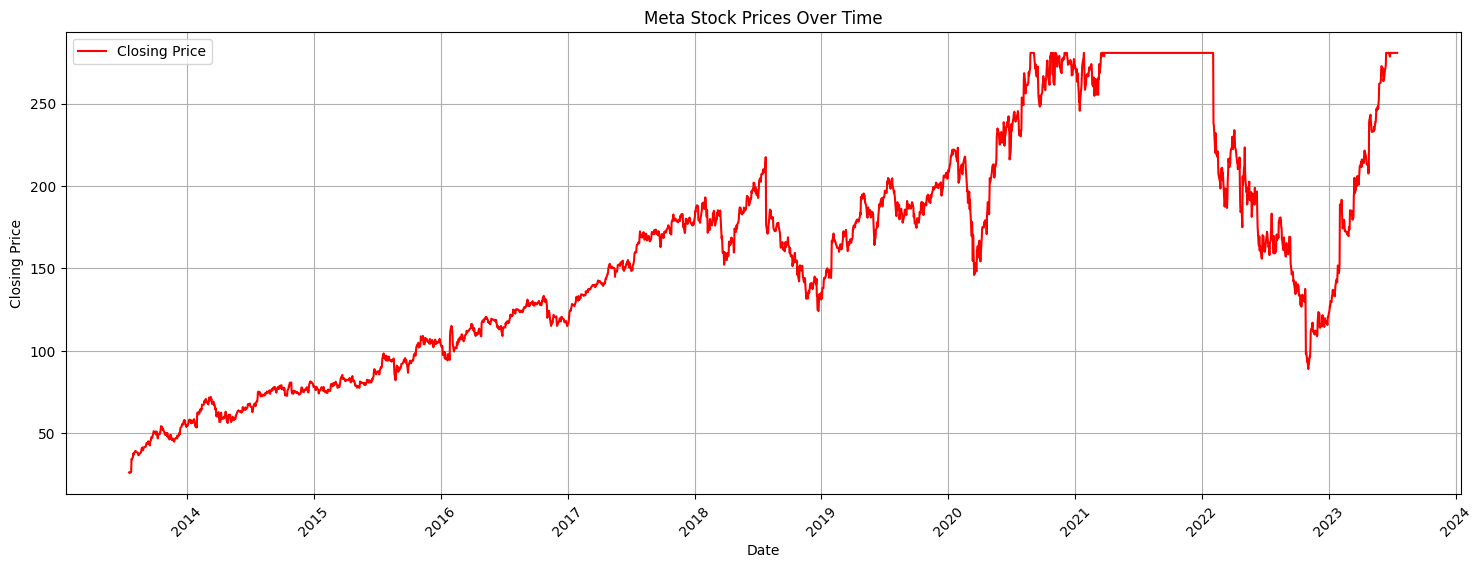

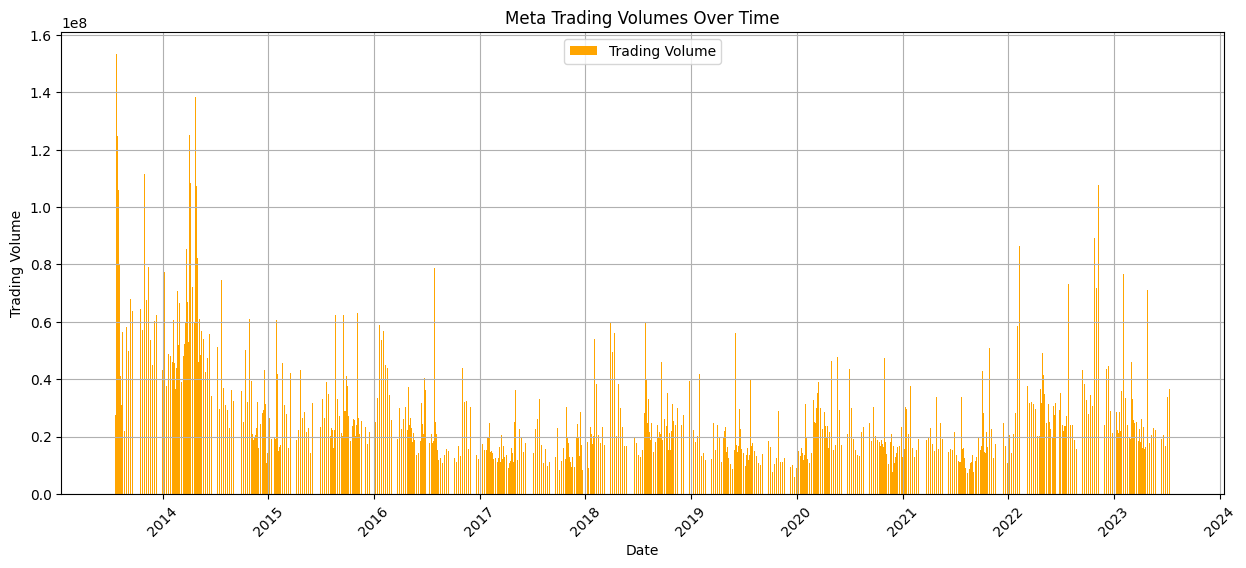

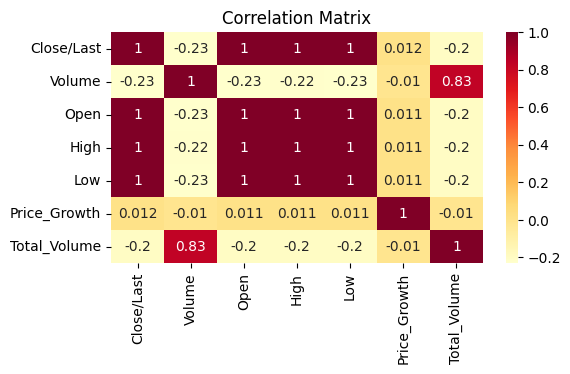

In [54]:
meta_data = stock_market[stock_market['Company'] == 'META']

plt.figure(figsize=(18, 6))
plt.plot(meta_data['Date'], meta_data['Close/Last'], color='red',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Meta Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(meta_data['Date'], meta_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Meta Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="YlOrRd")
plt.title('Correlation Matrix')
plt.show()

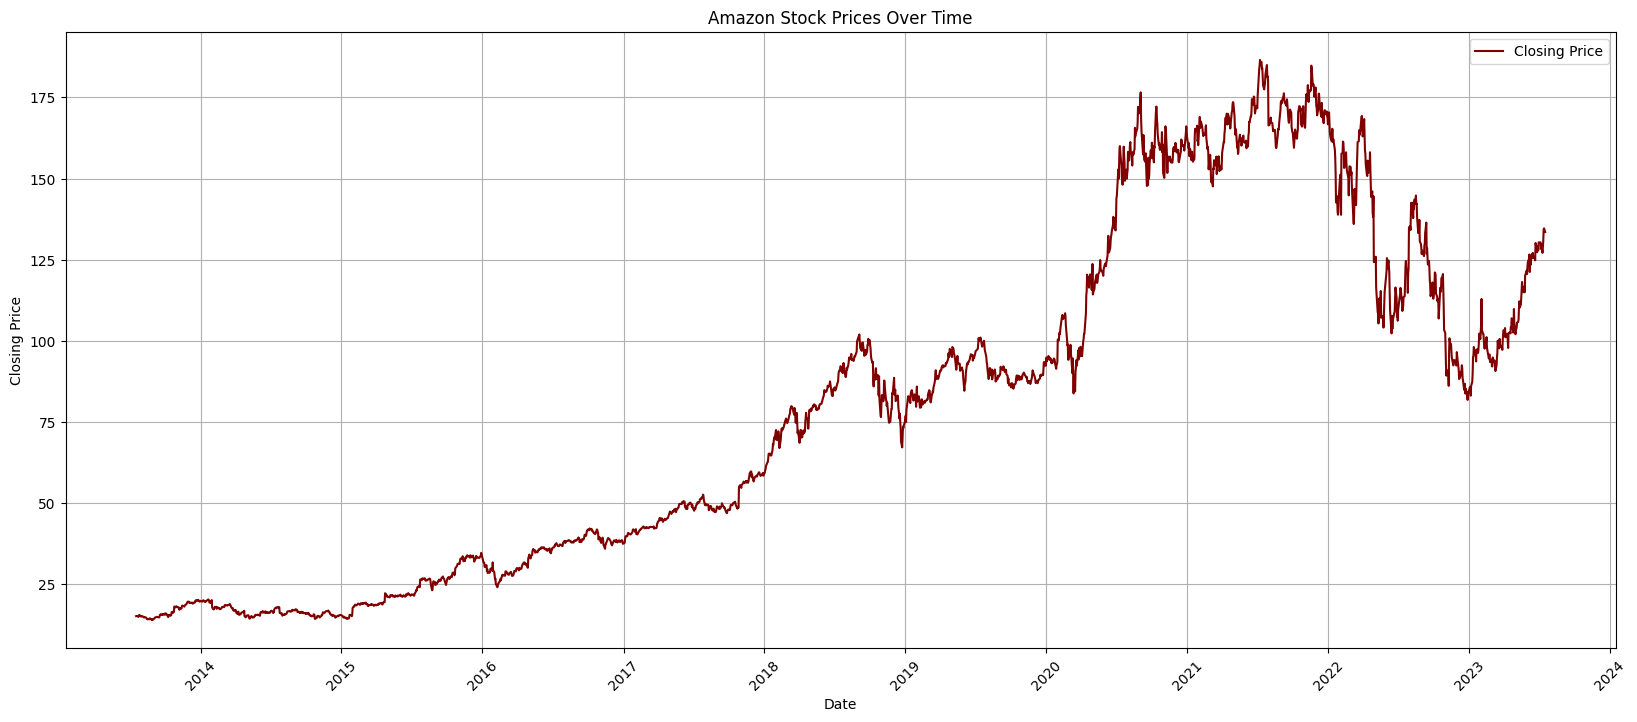

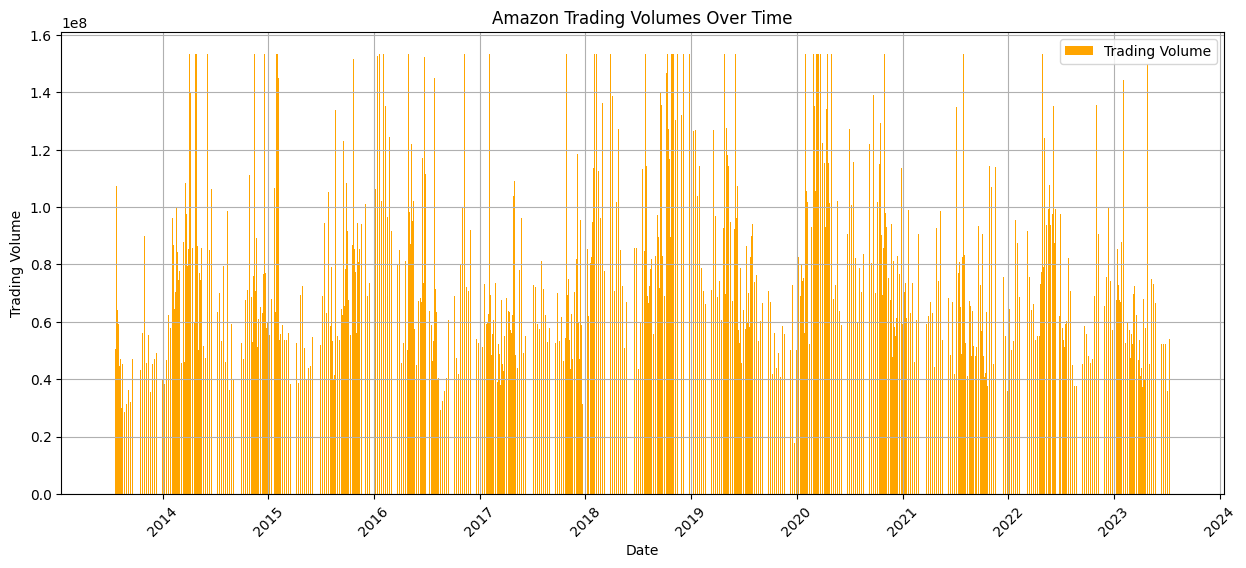

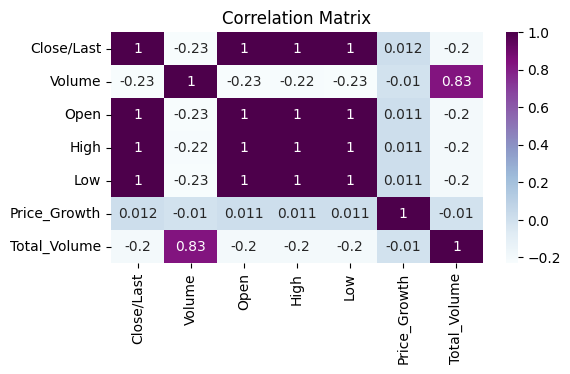

In [55]:
amazon_data = stock_market[stock_market['Company'] == 'AMZN']

plt.figure(figsize=(20, 8))
plt.plot(amazon_data['Date'], amazon_data['Close/Last'], color='maroon',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Amazon Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(amazon_data['Date'], amazon_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Amazon Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="BuPu")
plt.title('Correlation Matrix')
plt.show()

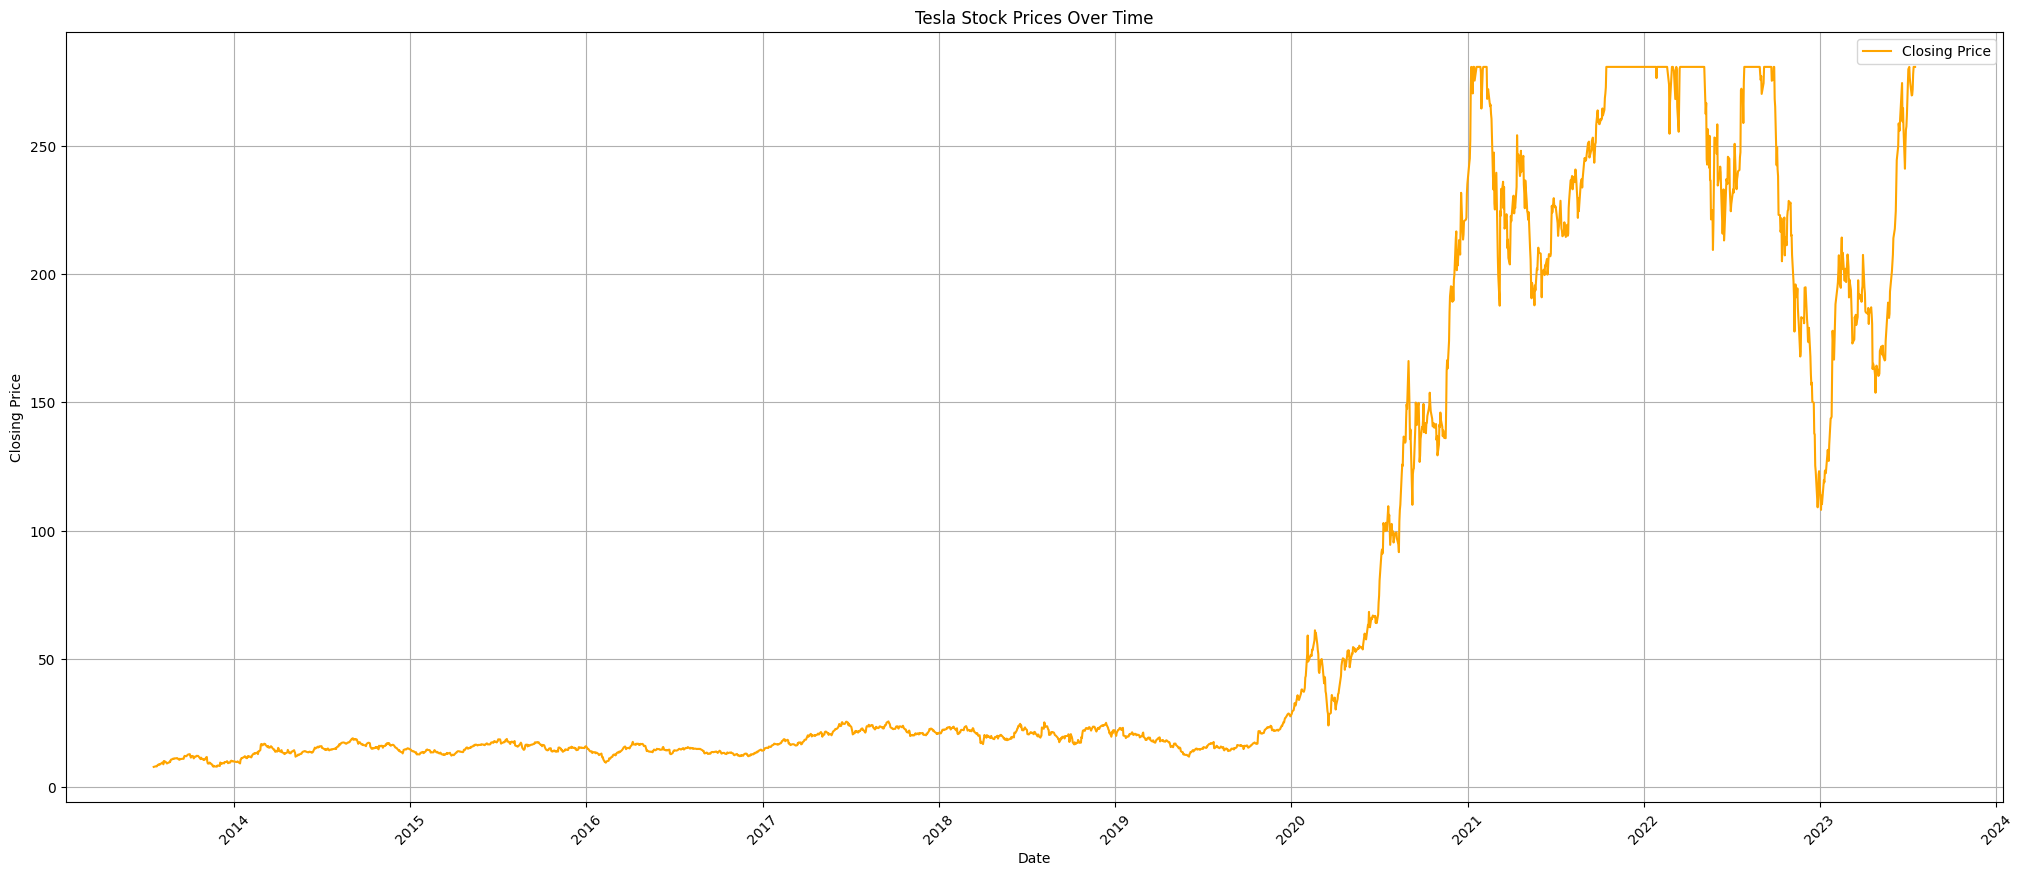

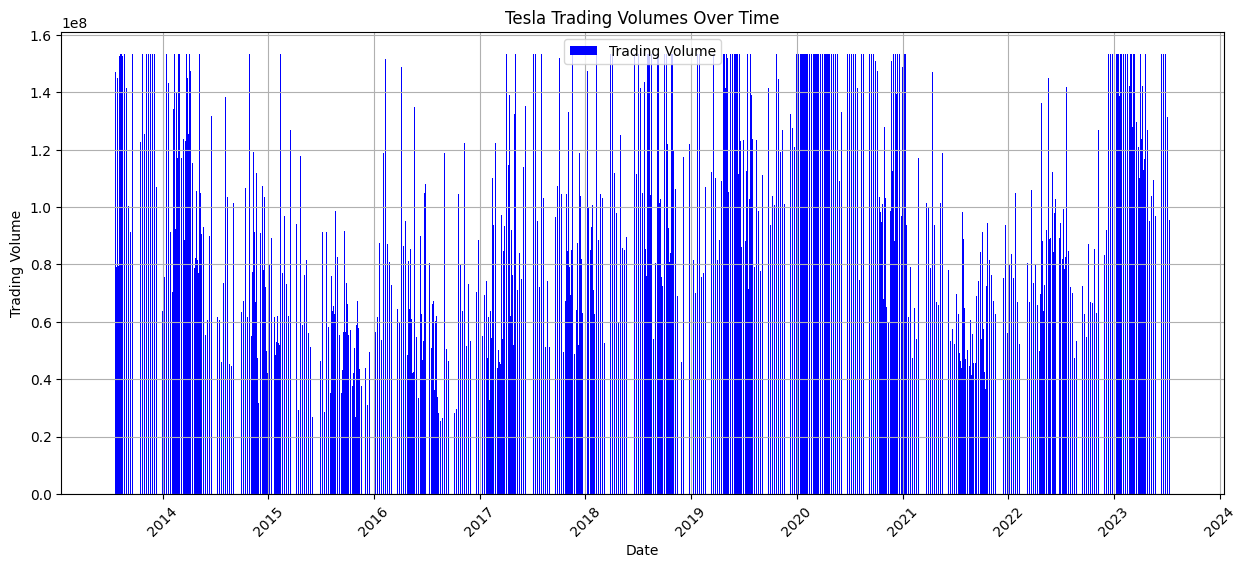

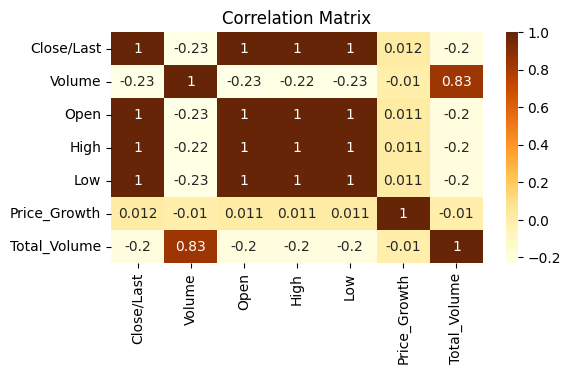

In [56]:
tesla_data = stock_market[stock_market['Company'] == 'TSLA']

plt.figure(figsize=(25, 10))
plt.plot(tesla_data['Date'], tesla_data['Close/Last'], color='orange',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Tesla Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(tesla_data['Date'], tesla_data['Volume'], label='Trading Volume', color='blue')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Tesla Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="YlOrBr")
plt.title('Correlation Matrix')
plt.show()

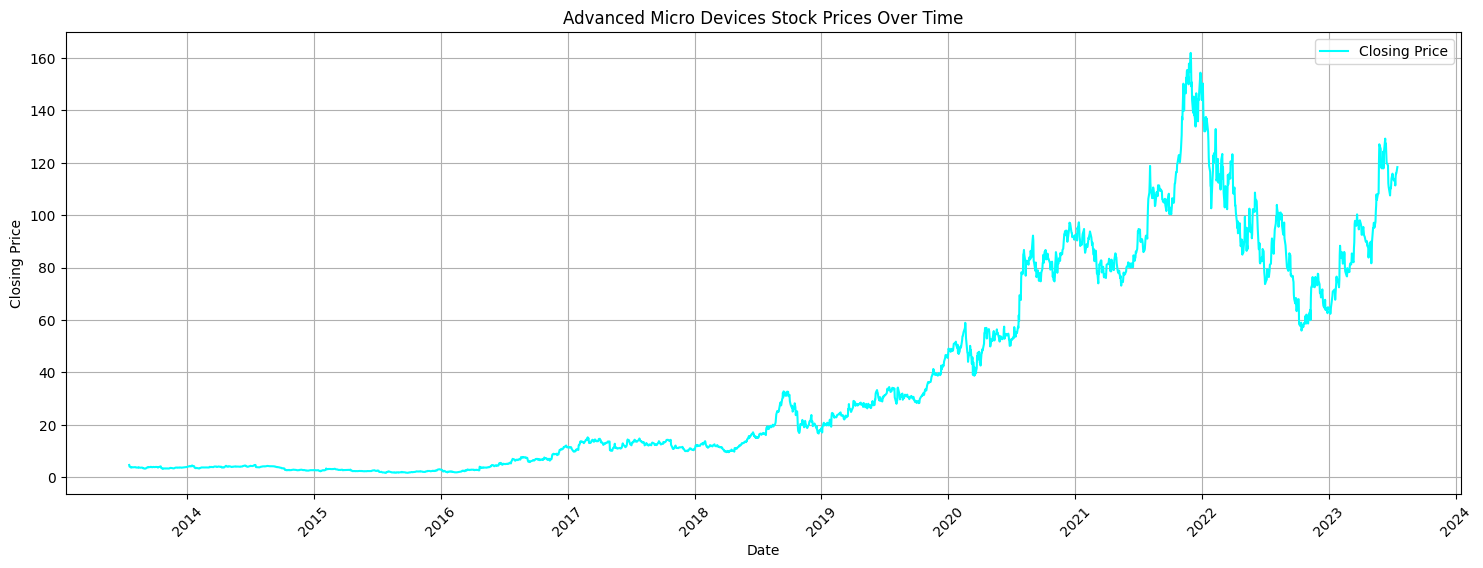

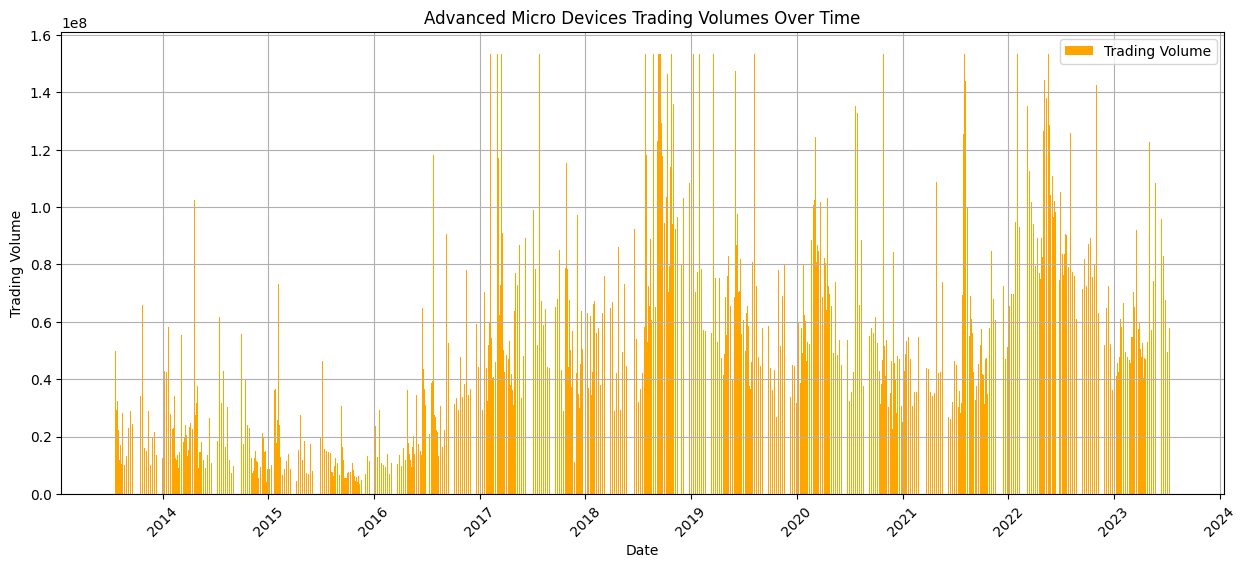

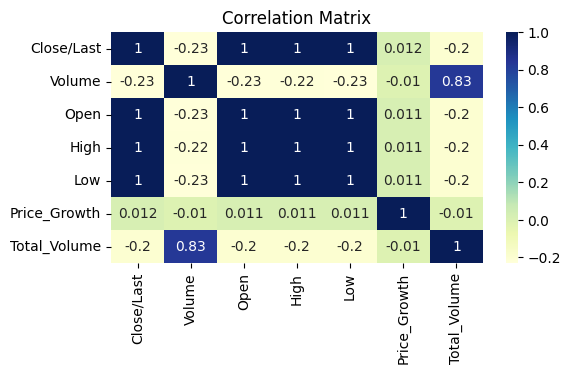

In [57]:
advanced_micro_devices_data = stock_market[stock_market['Company'] == 'AMD']

plt.figure(figsize=(18, 6))
plt.plot(advanced_micro_devices_data ['Date'],advanced_micro_devices_data ['Close/Last'], color='cyan',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Advanced Micro Devices Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(advanced_micro_devices_data ['Date'], advanced_micro_devices_data ['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Advanced Micro Devices Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="YlGnBu")
plt.title('Correlation Matrix')
plt.show()

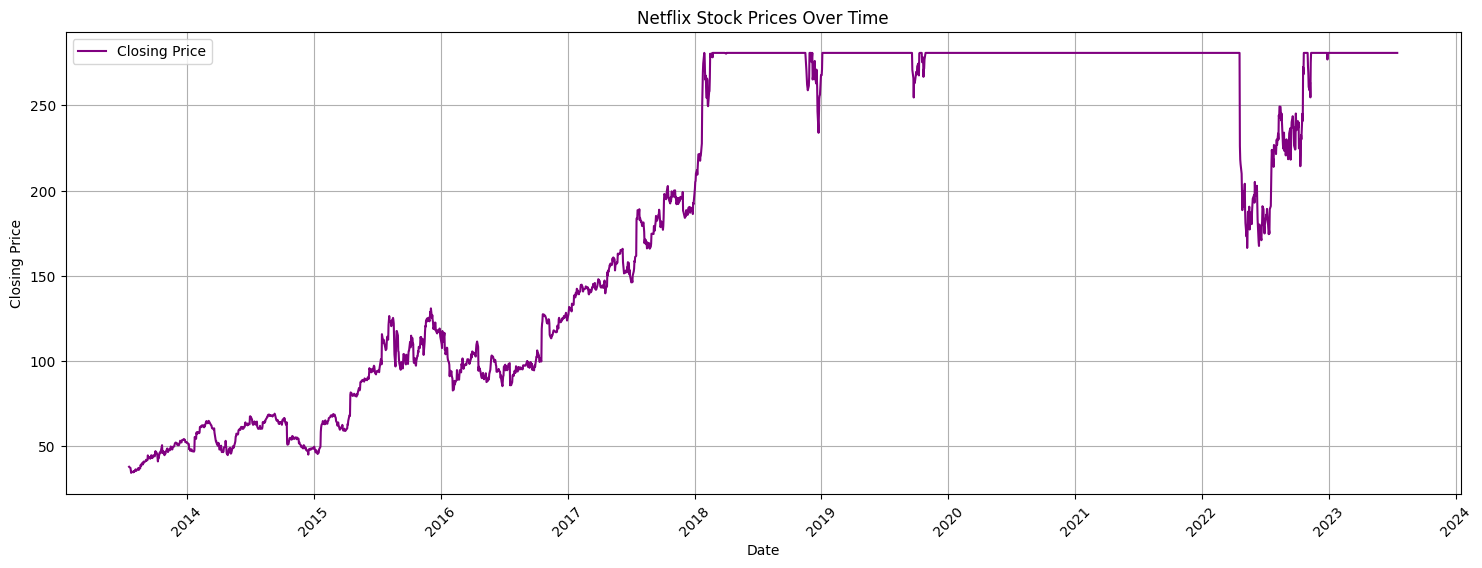

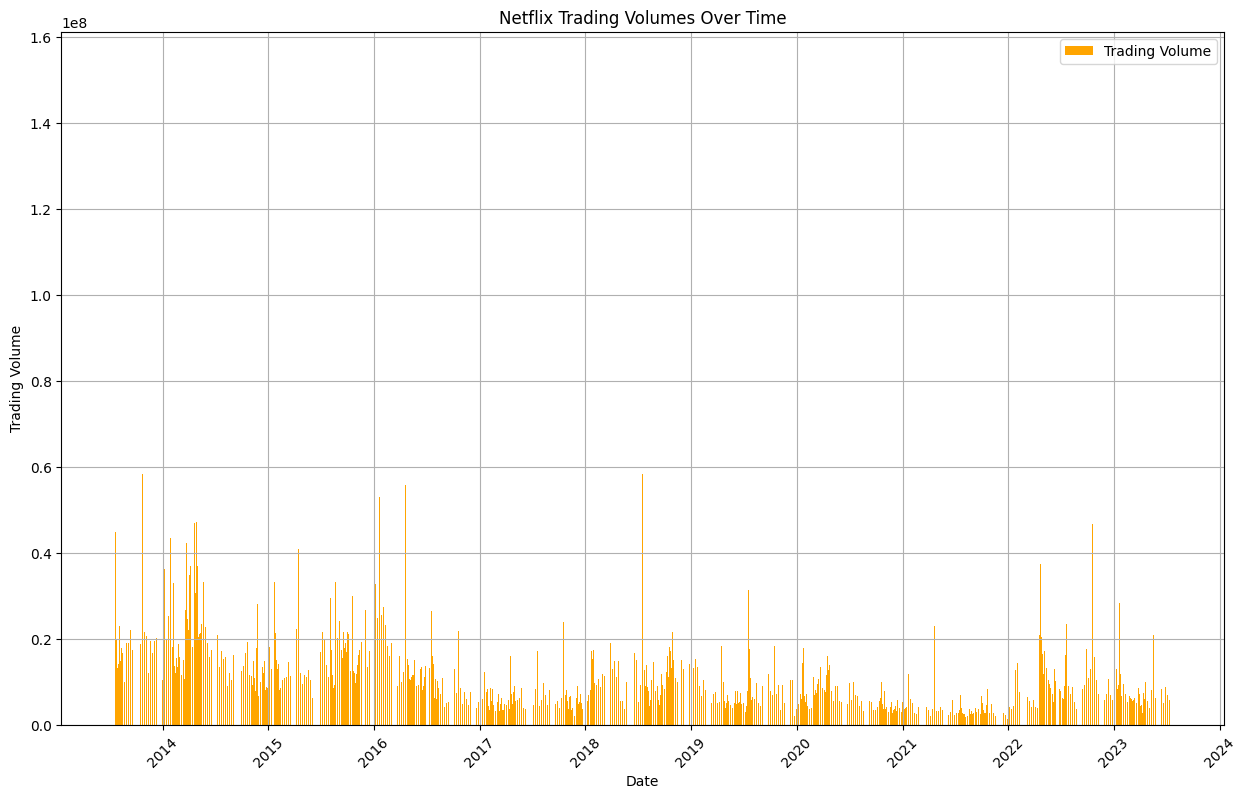

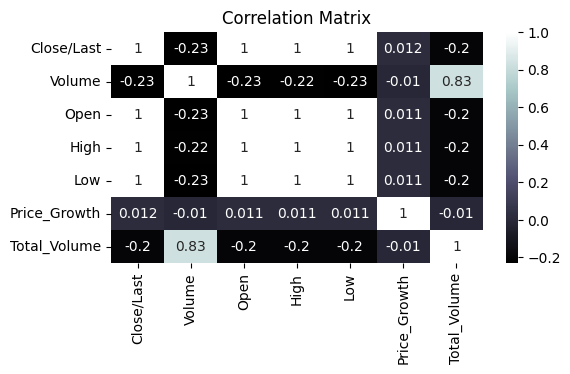

In [58]:
netflix_data = stock_market[stock_market['Company'] == 'NFLX']

plt.figure(figsize=(18, 6))
plt.plot(netflix_data['Date'], netflix_data['Close/Last'], color='purple',label='Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Netflix Stock Prices Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 9))
plt.bar(netflix_data ['Date'], netflix_data['Volume'], label='Trading Volume', color='orange')
plt.xlabel('Date')
plt.ylabel('Trading Volume')
plt.title('Netflix Trading Volumes Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

correlation_matrix = stock_market.corr(numeric_only=True)
plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,cmap="bone")
plt.title('Correlation Matrix')
plt.show()

In [59]:
stock_market['Price_Growth'] = stock_market.groupby('Company')['Close/Last'].pct_change() * 100
stock_market['Total_Volume'] = stock_market.groupby('Company')['Volume'].transform('sum')
top_performers_price = stock_market.groupby('Company')['Price_Growth'].mean().nlargest(5)
top_performers_volume = stock_market.groupby('Company')['Total_Volume'].mean().nlargest(5)
top_performers_price_df = pd.DataFrame({'Top Performers (Price Growth)': top_performers_price.index, 'Average Price Growth': top_performers_price.values})
top_performers_volume_df = pd.DataFrame({'Top Performers (Trading Volume)': top_performers_volume.index, 'Average Trading Volume': top_performers_volume.values})
result_table = pd.concat([top_performers_price_df, top_performers_volume_df], axis=1)
print(result_table)


  Top Performers (Price Growth)  Average Price Growth  \
0                          QCOM             -0.003706   
1                          CSCO             -0.014164   
2                          SBUX             -0.029417   
3                          NFLX             -0.057829   
4                           AMD             -0.063900   

  Top Performers (Trading Volume)  Average Trading Volume  
0                            AAPL            2.934375e+11  
1                            TSLA            2.477059e+11  
2                            AMZN            1.943811e+11  
3                             AMD            1.326395e+11  
4                            MSFT            7.810772e+10  


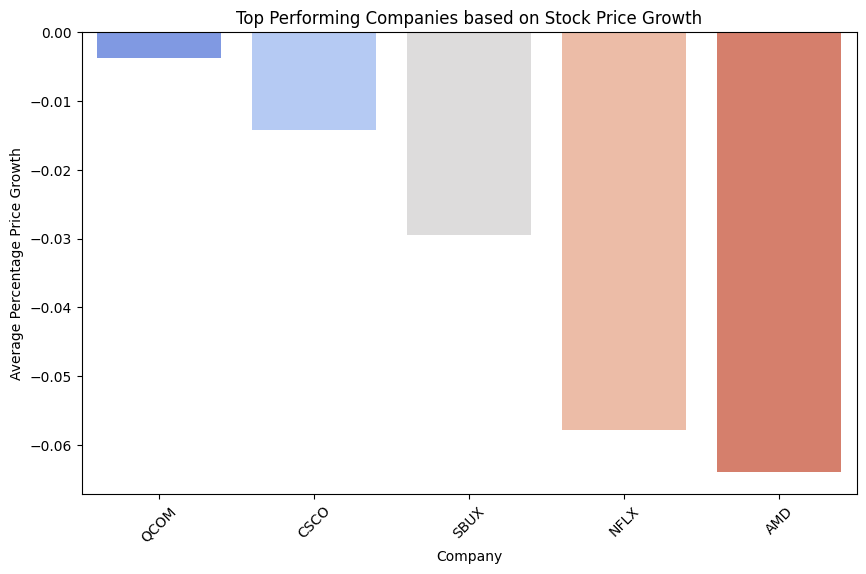

In [60]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_performers_price.index, y=top_performers_price.values, palette='coolwarm')
plt.title('Top Performing Companies based on Stock Price Growth')
plt.xlabel('Company')
plt.ylabel('Average Percentage Price Growth')
plt.xticks(rotation=45)
plt.show()


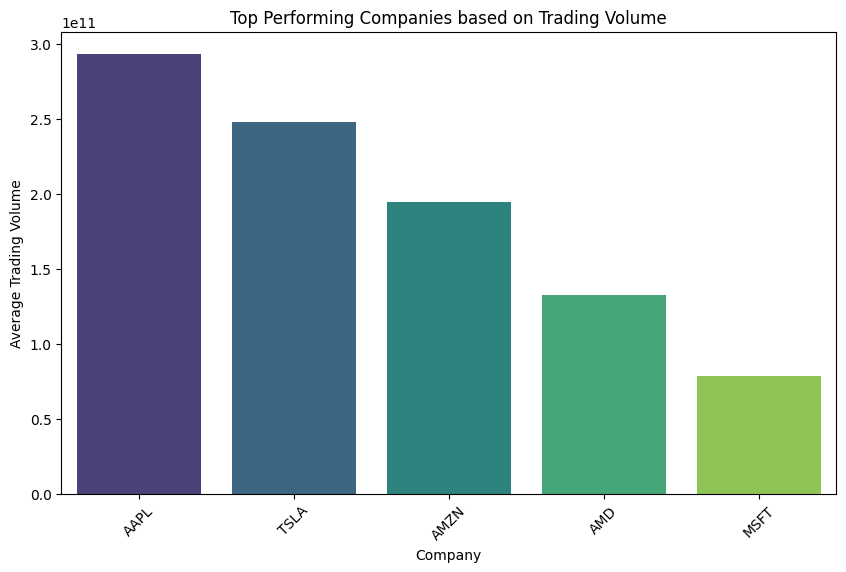

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_performers_volume.index, y=top_performers_volume.values, palette='viridis')
plt.title('Top Performing Companies based on Trading Volume')
plt.xlabel('Company')
plt.ylabel('Average Trading Volume')
plt.xticks(rotation=45)
plt.show()


In [62]:
volatility_df = stock_market.groupby('Company')['Close/Last'].std()
sorted_volatility_df = volatility_df.sort_values(ascending=False)
print(sorted_volatility_df)

Company
TSLA    97.594473
NFLX    93.332883
MSFT    89.296853
META    70.245279
AAPL    52.459923
AMZN    51.854820
AMD     39.991063
QCOM    34.979906
SBUX    23.795273
CSCO    11.089336
Name: Close/Last, dtype: float64


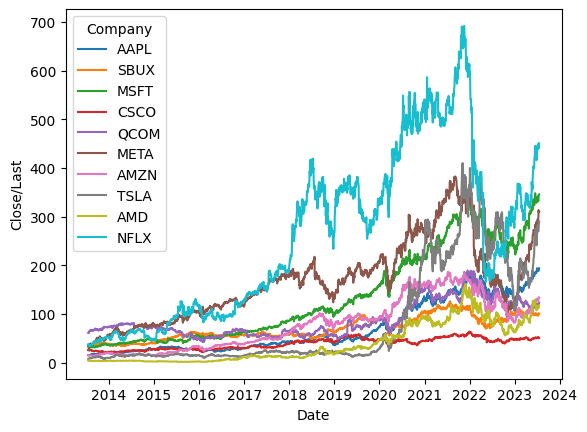

In [29]:
sns.lineplot(data=stock_market, x='Date', y='Close/Last', hue='Company')
plt.show()

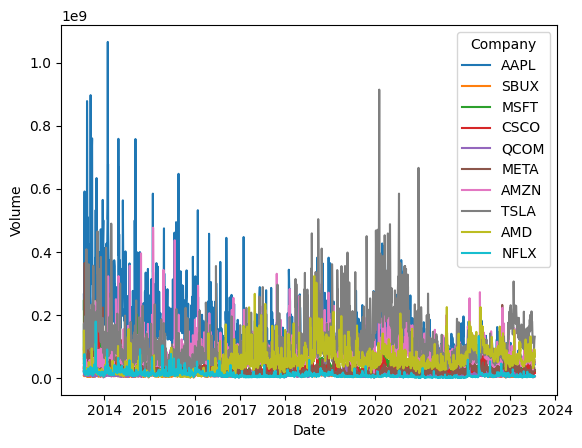

In [30]:
sns.lineplot(data=stock_market, x='Date', y='Volume', hue='Company')
plt.show()

In [63]:
stocks_close = stock_market.set_index(['Date', 'Company'])['Close/Last'].unstack()
stocks_close.head()


Company,AAPL,AMD,AMZN,CSCO,META,MSFT,NFLX,QCOM,SBUX,TSLA
Date,,,,,,,,,,
2013-07-18,15.4199,4.64,15.2055,25.86,26.180,35.44,38.0586,61.115,34.240,7.9353
2013-07-19,15.1768,4.03,15.2615,25.82,25.881,31.40,37.7966,61.460,34.395,7.9787
2013-07-22,15.2254,3.90,15.1740,25.72,26.045,32.01,37.4228,62.210,34.510,8.1620
2013-07-23,14.9639,3.66,15.0530,25.56,26.130,31.82,35.7514,62.300,33.830,8.1827
2013-07-24,15.7325,3.63,14.9470,25.59,26.510,31.96,34.4714,61.390,33.305,8.1133


In [64]:
stocks_daily_change = stocks_close.pct_change()
stocks_daily_change.head()

Company,AAPL,AMD,AMZN,CSCO,META,MSFT,NFLX,QCOM,SBUX,TSLA
Date,,,,,,,,,,
2013-07-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-07-19,-0.015765,-0.131466,0.003683,-0.001547,-0.011421,-0.113995,-0.006884,0.005645,0.004527,0.005469
2013-07-22,0.003202,-0.032258,-0.005733,-0.003873,0.006337,0.019427,-0.009890,0.012203,0.003344,0.022974
2013-07-23,-0.017175,-0.061538,-0.007974,-0.006221,0.003264,-0.005936,-0.044663,0.001447,-0.019704,0.002536
2013-07-24,0.051364,-0.008197,-0.007042,0.001174,0.014543,0.004400,-0.035803,-0.014607,-0.015519,-0.008481


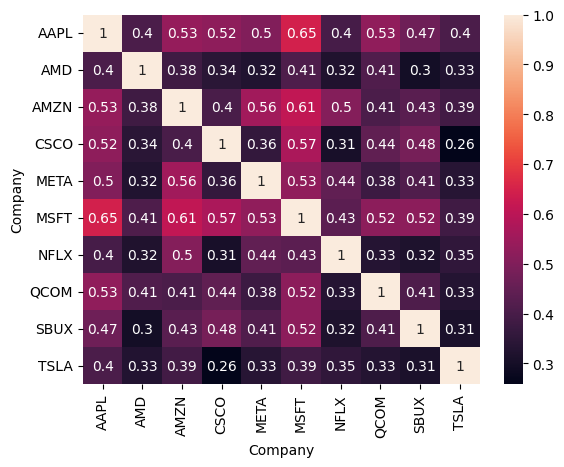

In [33]:
stocks_daily_change_corr = stocks_daily_change.corr()
sns.heatmap(stocks_daily_change_corr, annot=True)
plt.show()

In [34]:
stocks_close_after_2020 = stocks_close.loc['2020':]
stocks_close_after_2020.head()

Company,AAPL,AMD,AMZN,CSCO,META,MSFT,NFLX,QCOM,SBUX,TSLA
Date,,,,,,,,,,
2020-01-02,75.0875,49.10,94.9005,48.42,209.78,160.62,329.81,88.69,89.35,28.6840
2020-01-03,74.3575,48.60,93.7485,47.63,208.67,158.62,325.90,87.02,88.83,29.5340
2020-01-06,74.9500,48.39,95.1440,47.80,212.60,159.03,335.83,86.51,88.13,30.1027
2020-01-07,74.5975,48.25,95.3430,47.49,213.06,157.58,330.75,88.97,87.86,31.2707
2020-01-08,75.7975,47.83,94.5985,47.52,215.22,160.09,339.26,88.71,88.88,32.8093


In [35]:
price_changes_after_2020 = (stocks_close_after_2020.iloc[-1] / stocks_close_after_2020.iloc[0]-1).mul(100)
print('Top3 company is ', price_changes_after_2020.nlargest(3).index.to_list())
print("Top3 company's price change rate is ", price_changes_after_2020.nlargest(3).values, '%')

Top3 company is  ['TSLA', 'AAPL', 'AMD']
Top3 company's price change rate is  [912.34137498 158.35192276 140.97759674] %


         Std_annual
Company            
AMD        0.581313
TSLA       0.536546
META       0.369401
QCOM       0.350051
NFLX       0.331158
AMZN       0.329933
AAPL       0.285914
SBUX       0.261050
MSFT       0.260031
CSCO       0.251341


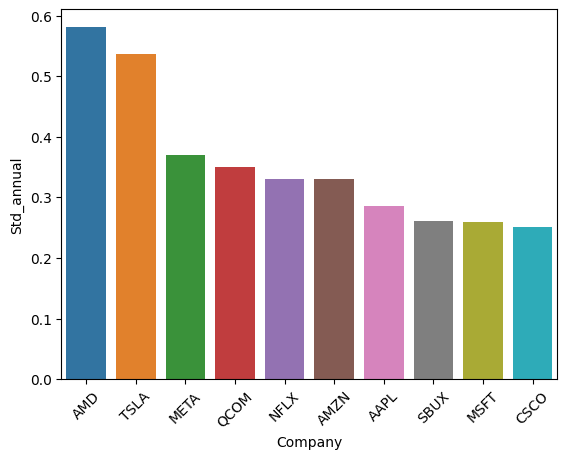

In [65]:
stocks_daily_change_volatility_annualized = pd.DataFrame(stocks_daily_change.std()*np.sqrt(252), columns=['Std_annual']).sort_values(by='Std_annual', ascending=False)
print(stocks_daily_change_volatility_annualized)

sns.barplot(data=stocks_daily_change_volatility_annualized, x=stocks_daily_change_volatility_annualized.index, y=stocks_daily_change_volatility_annualized.Std_annual)
plt.xticks(rotation=45)
plt.show()

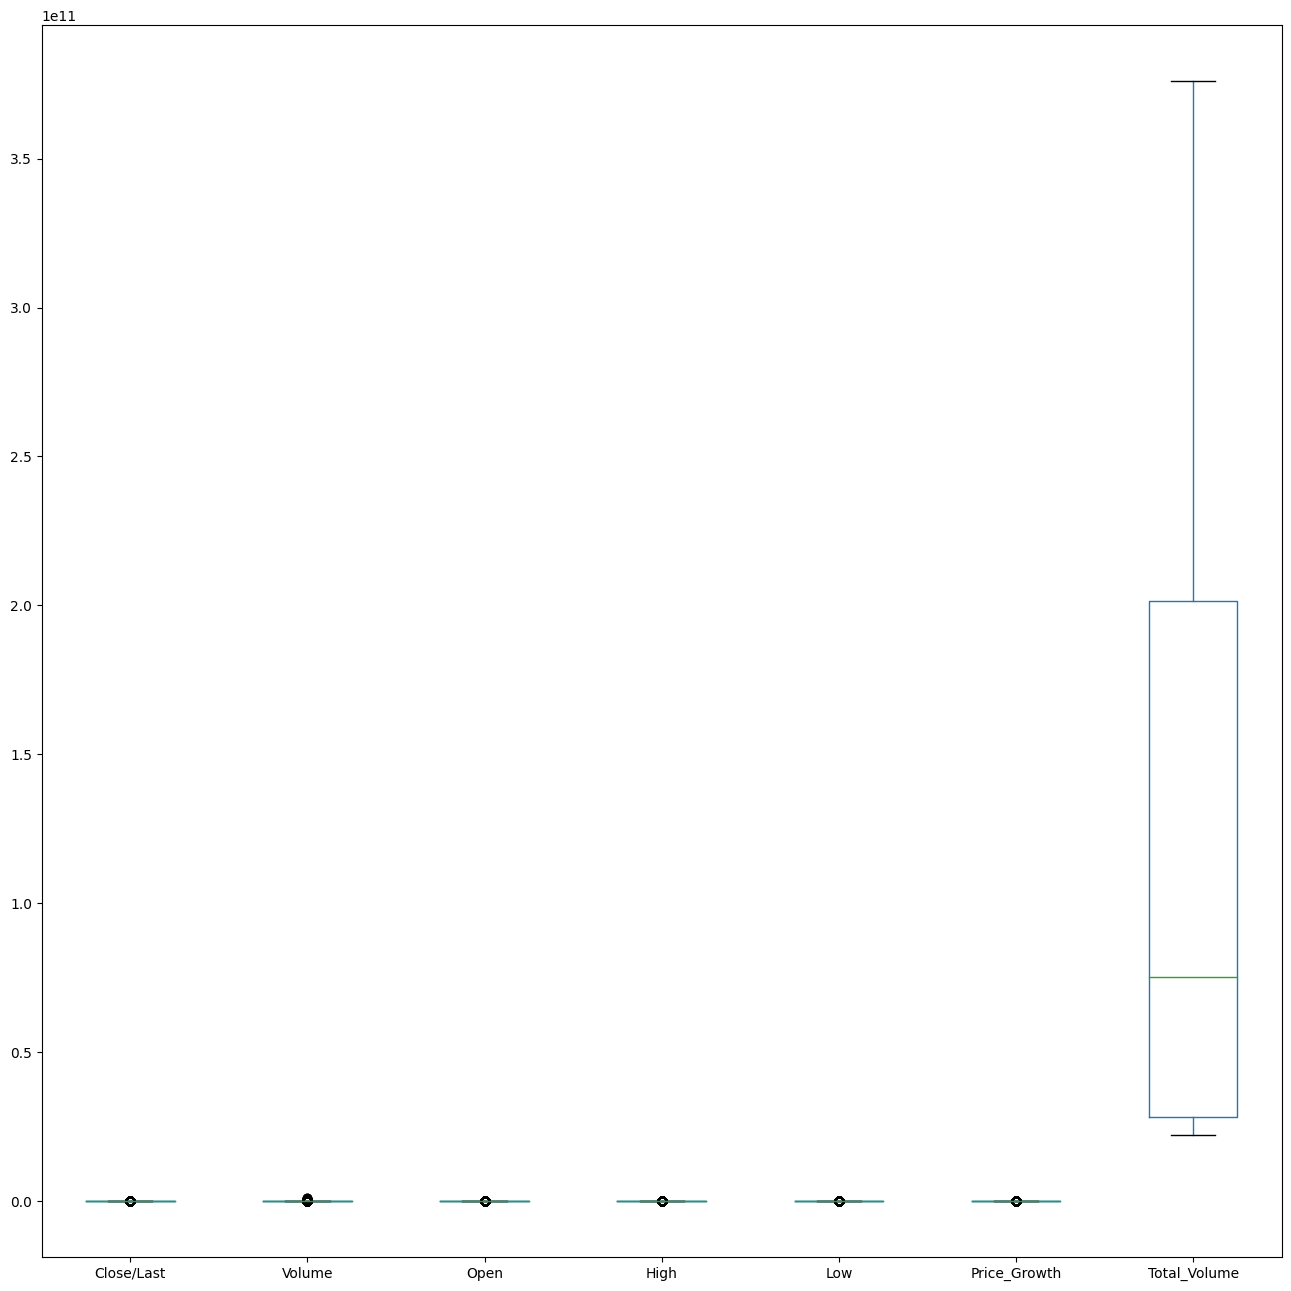

In [37]:
plt.figure(figsize=(16,16))
stock_market.boxplot(grid=False)
plt.xticks()
plt.show()

In [67]:
import numpy as np
col_names = ["Close/Last","Volume","Open","High","Low","Price_Growth"]

for col in col_names:
    if col not in stock_market.columns:
        print(f"'{col}' column does not exist in the DataFrame.")

for col in col_names:
    if col in stock_market.columns and stock_market[col].dtype != 'object':

        Q1 = np.nanpercentile(stock_market[col], 25)
        Q3 = np.nanpercentile(stock_market[col], 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        stock_market[col] = np.where(stock_market[col] < lower_bound, lower_bound, stock_market[col])
        stock_market[col] = np.where(stock_market[col] > upper_bound, upper_bound, stock_market[col])

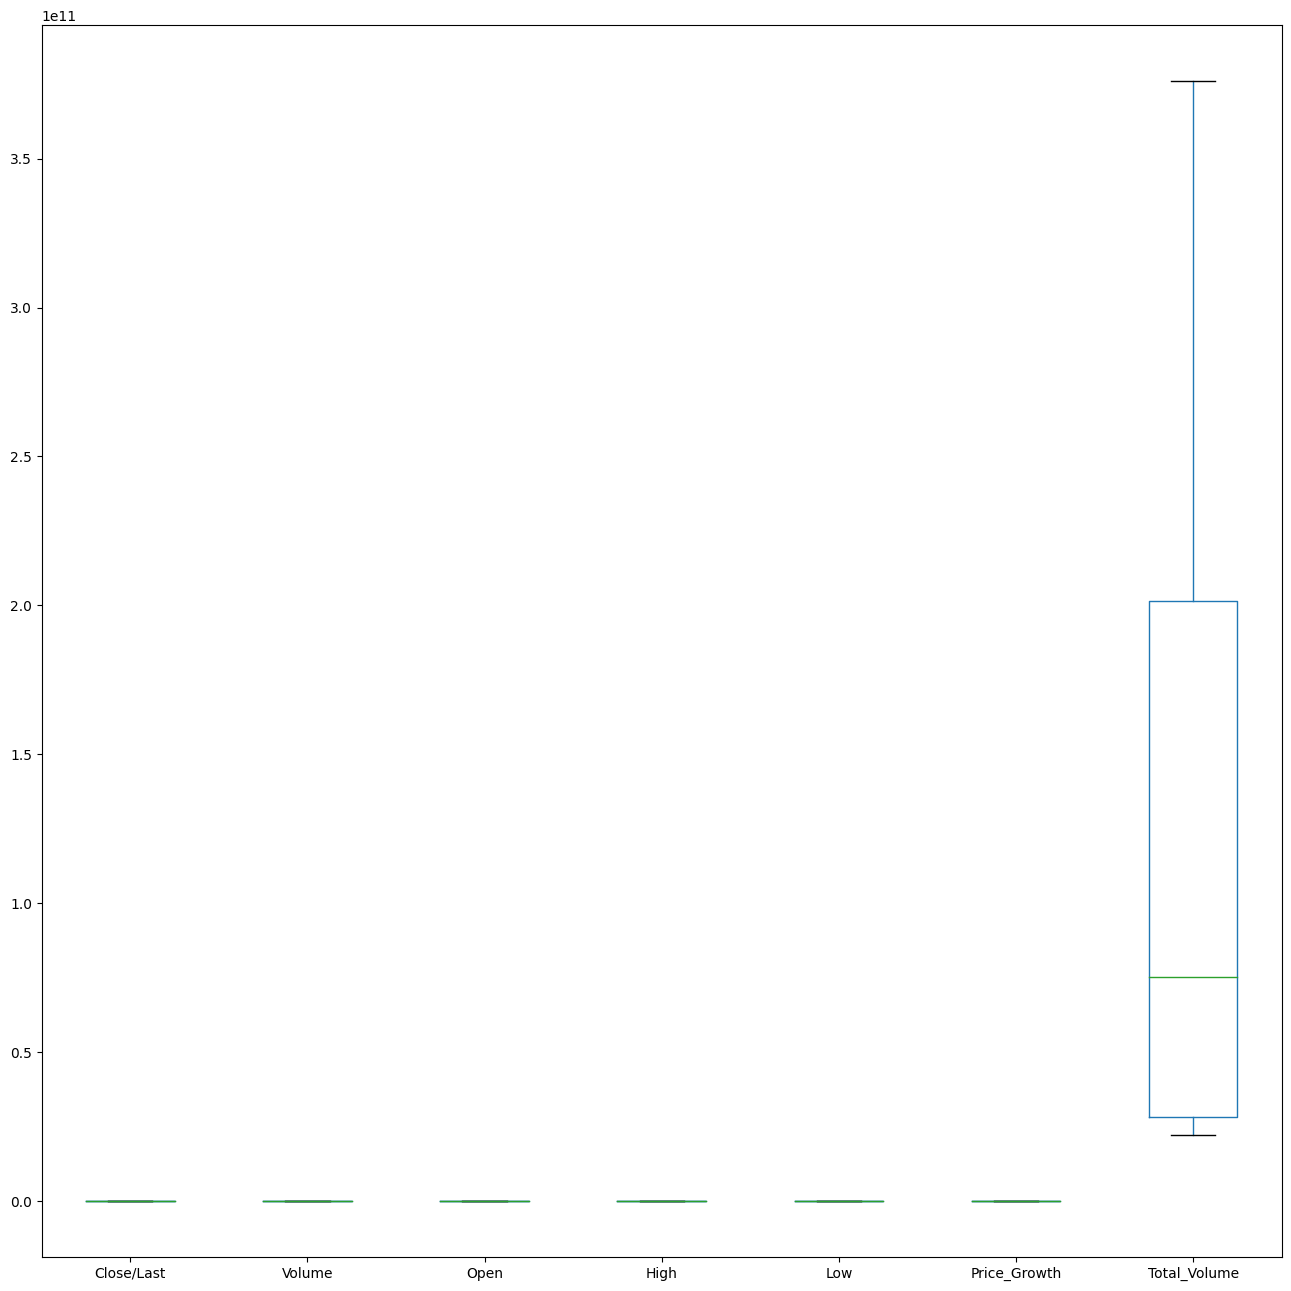

In [39]:
plt.figure(figsize=(16,16))
stock_market.boxplot(grid=False)
plt.xticks()
plt.show()

In [40]:
x = stock_market.drop('Close/Last', axis=1)
y = stock_market['Close/Last']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=42)

In [68]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

y = stock_market['Close/Last']
X = stock_market.drop(['Company', 'Date', 'Close/Last'], axis=1)
categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

regressor = xgb.XGBRegressor()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Mean Squared Error: 1.2834713997895801
R-squared: 0.9997937547904487
Mean Absolute Error: 0.6050098381206975


In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_imputed, y_train)

X_test_imputed = imputer.transform(X_test)

y_pred = regressor.predict(X_test_imputed)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)



Mean Squared Error: 1.0611426728482543
R-squared: 0.999829481519447
Mean Absolute Error: 0.5091074783552784


In [70]:
from sklearn.ensemble import GradientBoostingRegressor

regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_imputed, y_train)

y_pred = regressor.predict(X_test_imputed)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Gradient Boosting Regressor Results:")
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Gradient Boosting Regressor Results:
Mean Squared Error: 1.637395914605556
R-squared: 0.9997368815046587
Mean Absolute Error: 0.7566566940829521


In [71]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
regressor = SVR(kernel='linear')
regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Support Vector Machine (SVM) Regressor Results:")
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Support Vector Machine (SVM) Regressor Results:
Mean Squared Error: 1.1391708602957777
R-squared: 0.999816942915257
Mean Absolute Error: 0.5509363062456182


In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

features = stock_market[['Volume', 'Open', 'High', 'Low']]
target = stock_market['Close/Last']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training Data Metrics:")
print(f"Mean Squared Error: {train_mse}")
print(f"R-squared: {train_r2}")
print(f"Mean Absolute Error: {train_mae}")

print("\nTest Data Metrics:")
print(f"Mean Squared Error: {test_mse}")
print(f"R-squared: {test_r2}")
print(f"Mean Absolute Error: {test_mae}")


Training Data Metrics:
Mean Squared Error: 0.9191235551630964
R-squared: 0.9998566930562477
Mean Absolute Error: 0.4927375424990825

Test Data Metrics:
Mean Squared Error: 0.8335665904735853
R-squared: 0.999868043811771
Mean Absolute Error: 0.49616833362998053


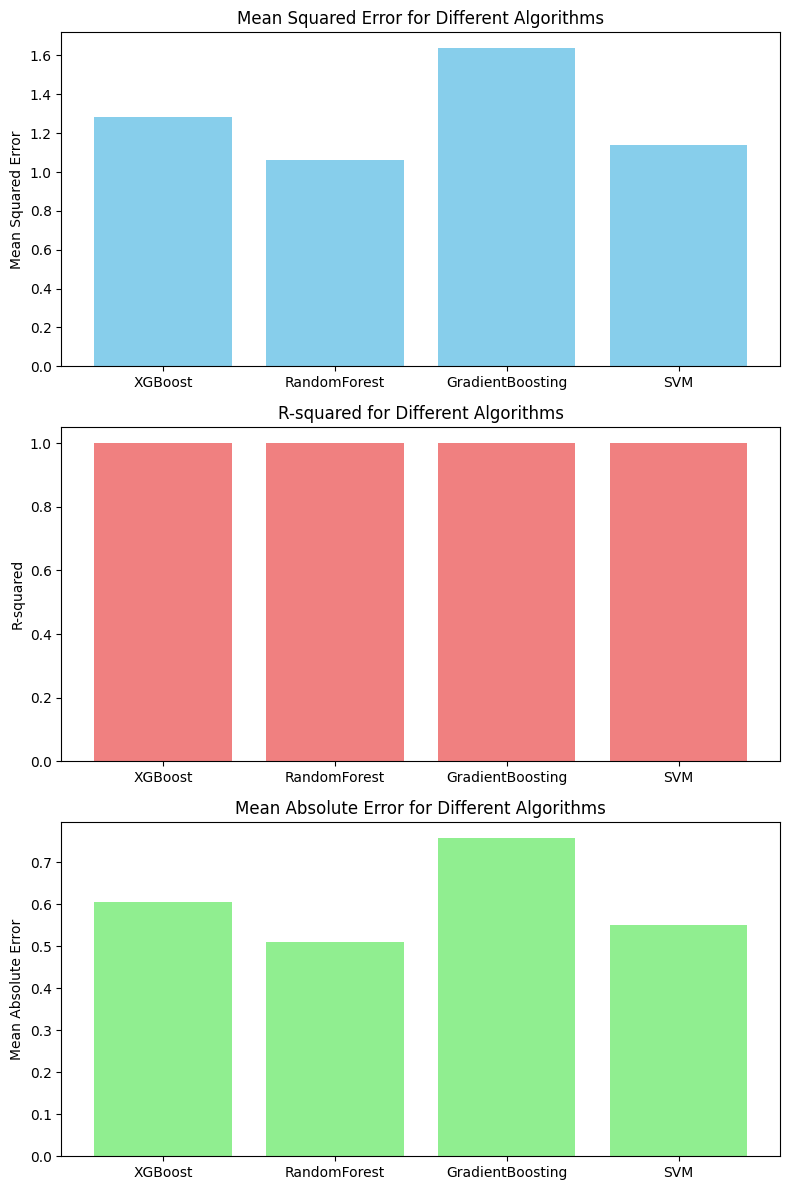

In [73]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

y = stock_market['Close/Last']

X = stock_market.drop(['Company', 'Date', 'Close/Last'], axis=1)

categorical_columns = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

xgboost_regressor = xgb.XGBRegressor()
xgboost_regressor.fit(X_train, y_train)
y_pred_xgboost = xgboost_regressor.predict(X_test)
mse_xgboost = mean_squared_error(y_test, y_pred_xgboost)
r2_xgboost = r2_score(y_test, y_pred_xgboost)
mae_xgboost = mean_absolute_error(y_test, y_pred_xgboost)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
randomforest_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
randomforest_regressor.fit(X_train_imputed, y_train)
y_pred_randomforest = randomforest_regressor.predict(X_test_imputed)
mse_randomforest = mean_squared_error(y_test, y_pred_randomforest)
r2_randomforest = r2_score(y_test, y_pred_randomforest)
mae_randomforest = mean_absolute_error(y_test, y_pred_randomforest)

gradientboost_regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradientboost_regressor.fit(X_train_imputed, y_train)
y_pred_gradientboost = gradientboost_regressor.predict(X_test_imputed)
mse_gradientboost = mean_squared_error(y_test, y_pred_gradientboost)
r2_gradientboost = r2_score(y_test, y_pred_gradientboost)
mae_gradientboost = mean_absolute_error(y_test, y_pred_gradientboost)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
svm_regressor = SVR(kernel='linear')
svm_regressor.fit(X_train_scaled, y_train)
y_pred_svm = svm_regressor.predict(X_test_scaled)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)

algorithms = ["XGBoost", "RandomForest", "GradientBoosting", "SVM"]
mse_values = [mse_xgboost, mse_randomforest, mse_gradientboost, mse_svm]
r2_values = [r2_xgboost, r2_randomforest, r2_gradientboost, r2_svm]
mae_values = [mae_xgboost, mae_randomforest, mae_gradientboost, mae_svm]

fig, axs = plt.subplots(3, 1, figsize=(8, 12))

axs[0].bar(algorithms, mse_values, color='skyblue')
axs[0].set_ylabel('Mean Squared Error')
axs[0].set_title('Mean Squared Error for Different Algorithms')
axs[1].bar(algorithms, r2_values, color='lightcoral')
axs[1].set_ylabel('R-squared')
axs[1].set_title('R-squared for Different Algorithms')

axs[2].bar(algorithms, mae_values, color='lightgreen')
axs[2].set_ylabel('Mean Absolute Error')
axs[2].set_title('Mean Absolute Error for Different Algorithms')

plt.tight_layout()

plt.show()


**CONCLUSION**

Among the four regression models assessed, XGBoost and Random Forest stand out for their robust predictive capabilities. They both exhibit minimal mean squared error (MSE) and mean absolute error (MAE), signifying their proficiency in making precise forecasts. XGBoost, in particular, boasts a slightly superior R-squared value, implying a stronger data fit. Gradient Boosting and Support Vector Machine (SVM) regression models, while still performing well, display slightly higher prediction errors when compared to XGBoost and Random Forest. In summary, XGBoost emerges as the top-performing model for this stock price prediction task, with Random Forest as a close contender. The choice between these two models may depend on specific requirements, striking a balance between prediction accuracy and computational complexity.